# The Noncommutative Connes-Kreimer (NCK) Hopf Algebra

This notebook demonstrates the **noncommutative Connes-Kreimer (NCK) Hopf algebra**
as implemented in the `kauri` package.

The NCK Hopf algebra is the planar (noncommutative) analogue of the
classical Butcher-Connes-Kreimer (BCK) Hopf algebra. It is defined on
**planar rooted trees** (also called ordered or plane trees), where the
left-to-right ordering of siblings is significant. The forest
multiplication is **noncommutative** (ordered concatenation), and the
unit element is the empty tree $\emptyset$.

The NCK Hopf algebra was introduced by Foissy in the context of
combinatorial Dyson-Schwinger equations:

> L. Foissy, *Les alg\`ebres de Hopf des arbres enracin\'es d\'ecor\'es*, Ph.D. thesis,
> Universit\'e de Reims, 2002.

See also:

> L. Foissy, *Fa\`a di Bruno subalgebras of the Hopf algebra of planar trees
> from combinatorial Dyson-Schwinger equations*,
> Advances in Mathematics **218** (2008), 136--162. arXiv: [0707.1204](https://arxiv.org/abs/0707.1204).

In [1]:
import kauri as kr
import kauri.nck as nck

PT = kr.PlanarTree

## 1. Planar trees

A **planar tree** (or ordered rooted tree) is a rooted tree in which the
children of every node carry a fixed left-to-right ordering. In `kauri`,
planar trees are represented by the `PlanarTree` class.

The empty tree is `PlanarTree(None)`, the single-node tree (bullet
$\bullet$) is `PlanarTree([])`, and larger trees are built by listing
child sub-representations inside brackets.

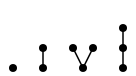

In [2]:
# Some small planar trees
bullet = PT([])          # order 1: bullet
chain2 = PT([[]])        # order 2: chain of length 2
cherry = PT([[], []])    # order 3: cherry (Y-shape)
chain3 = PT([[[]]])      # order 3: chain of length 3

kr.display(bullet, chain2, cherry, chain3)

### Planar order matters

Unlike non-planar `Tree` objects, two `PlanarTree` objects with the same
underlying graph but different sibling orderings are **distinct**. For
example, the following two order-4 trees have the same shape as
non-planar trees, but differ in the planar sense because the chain
subtree and the bullet subtree are swapped:

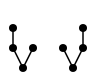

Equal? False


In [3]:
t_left  = PT([[[]], []])   # chain2 on the left, bullet on the right
t_right = PT([[], [[]]])   # bullet on the left, chain2 on the right

kr.display(t_left, t_right)
print("Equal?", t_left == t_right)

### Noncommutative forest multiplication

Multiplying two planar trees produces an `OrderedForest` via ordered
concatenation. Since the ordering is preserved, $t_1 \cdot t_2 \neq t_2 \cdot t_1$
in general:

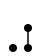

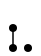

f1 == f2? False


In [4]:
f1 = bullet * chain2   # bullet then chain2
f2 = chain2 * bullet   # chain2 then bullet

kr.display(f1)
kr.display(f2)
print("f1 == f2?", f1 == f2)

## 2. Coproduct

The NCK coproduct is defined via **admissible cuts** on planar trees,
preserving the planar ordering of siblings:

$$\Delta_{\mathrm{NCK}}(t) = t \otimes \emptyset + \emptyset \otimes t
    + \sum_{c} P_c(t) \otimes R^c(t)$$

where the sum is over all admissible cuts $c$, $P_c(t)$ is the pruned
(cut-off) ordered forest, and $R^c(t)$ is the trunk (remaining subtree).

We verify the coproduct values below against Foissy (2008),
arXiv [0707.1204](https://arxiv.org/abs/0707.1204).

### Basic examples

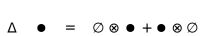

In [5]:
kr.display("Δ", bullet, "=", nck.coproduct(bullet))

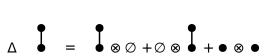

In [6]:
kr.display("Δ", chain2, "=", nck.coproduct(chain2))

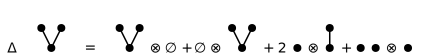

In [7]:
kr.display("Δ", cherry, "=", nck.coproduct(cherry))

### Key planar example from Foissy (2008)

The trees $B_+(B_+(\bullet),\, \bullet)$ and $B_+(\bullet,\, B_+(\bullet))$
are distinct in the planar setting. Their coproducts differ because the
admissible cuts respect the sibling ordering.

Verified against Foissy (2008), arXiv 0707.1204, lines 134--139.

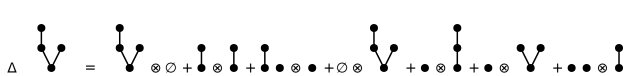

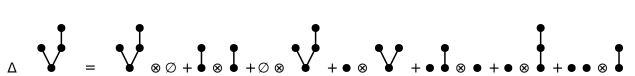

Are the two coproducts equal? False


In [8]:
t_left  = PT([[[]], []])   # B+(chain2, bullet)
t_right = PT([[], [[]]])   # B+(bullet, chain2)

kr.display("Δ", t_left, "=", nck.coproduct(t_left))
kr.display("Δ", t_right, "=", nck.coproduct(t_right))

print("Are the two coproducts equal?", nck.coproduct(t_left) == nck.coproduct(t_right))

### Corolla coproduct formula

For the corolla $B_+(\bullet^n)$ (a root with $n$ leaf children), the
coproduct takes a particularly clean form with binomial coefficients:

$$\Delta\bigl(B_+(\bullet^n)\bigr) = B_+(\bullet^n) \otimes \emptyset
    + \sum_{k=0}^{n} \binom{n}{k}\, \bullet^k \otimes B_+(\bullet^{n-k})
    + \emptyset \otimes B_+(\bullet^n)$$

Note that the term for $k=0$ in the sum yields
$\emptyset \otimes B_+(\bullet^n)$, which combines with the trailing
term. The binomial coefficients here match the BCK (commutative) case
because all children are identical bullets, so the planar ordering is
irrelevant.

Verified against Foissy (2008), part2.tex, lines 120--122.

We verify this for $n = 1, 2, 3, 4$:

In [9]:
from math import comb

for n in range(1, 5):
    corolla = PT([[] for _ in range(n)])   # B+(bullet^n)
    cp = nck.coproduct(corolla)

    # Build expected coproduct using the binomial formula
    # B+(bullet^n) x empty  +  sum_{k=0}^{n} C(n,k) * bullet^k x B+(bullet^{n-k})
    # where B+(bullet^0) = B+(empty) = bullet, and bullet^0 = empty forest
    expected = corolla @ PT(None)          # corolla tensor empty
    for k in range(n + 1):
        left = bullet ** k if k > 0 else PT(None)
        # B+(bullet^{n-k}): when n-k=0, B+(empty) = bullet
        m = n - k
        right = PT([[] for _ in range(m)]) if m > 0 else bullet
        expected = expected + comb(n, k) * (left @ right)

    expected = expected.simplify()
    print(f"n={n}: coproduct matches formula?", cp == expected)

n=1: coproduct matches formula? True
n=2: coproduct matches formula? True
n=3: coproduct matches formula? True
n=4: coproduct matches formula? True


## 3. Antipode

The antipode $S_{\mathrm{NCK}}$ of the NCK Hopf algebra is defined
recursively by $S(\emptyset) = \emptyset$, $S(\bullet) = -\bullet$, and

$$S(t) = -t - \sum_{c} S\bigl(P_c(t)\bigr)\, R^c(t)$$

where the sum is over admissible cuts $c$.

Because the NCK algebra is **neither commutative nor cocommutative**,
the antipode is an **anti-homomorphism**: $S(t_1 t_2) = S(t_2)\, S(t_1)$,
and in general $S^2 \neq \mathrm{id}$.

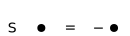

In [10]:
kr.display("S", bullet, "=", nck.antipode(bullet))

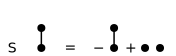

In [11]:
kr.display("S", chain2, "=", nck.antipode(chain2))

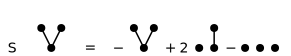

In [12]:
# Note: the ordered forest bullet * chain2 means bullet THEN chain2
kr.display("S", cherry, "=", nck.antipode(cherry))

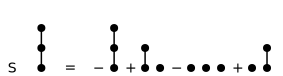

In [13]:
kr.display("S", chain3, "=", nck.antipode(chain3))

### $S^2 \neq \mathrm{id}$ in general

In the commutative BCK algebra, $S^2 = \mathrm{id}$. This fails for NCK
because the algebra is noncommutative and the coalgebra is
non-cocommutative. However, $S^2 = \mathrm{id}$ still holds for
**primitive** elements (elements $t$ with
$\Delta(t) = t \otimes \emptyset + \emptyset \otimes t$), such as
the chain trees.

In [14]:
S_squared = nck.antipode & nck.antipode

# Chain trees: S^2 = id
print("S^2(bullet) == bullet?", S_squared(bullet) == bullet)
print("S^2(chain2) == chain2?", S_squared(chain2) == chain2)
print("S^2(chain3) == chain3?", S_squared(chain3) == chain3)

# Cherry tree: S^2 != id
print("S^2(cherry) == cherry?", S_squared(cherry) == cherry)

S^2(bullet) == bullet? True
S^2(chain2) == chain2? True
S^2(chain3) == chain3? True
S^2(cherry) == cherry? False


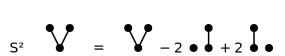

In [15]:
kr.display("S²", cherry, "=", S_squared(cherry))

## 4. Hopf algebra axioms

### Counit

The counit $\varepsilon$ satisfies $\varepsilon(\emptyset) = 1$ and
$\varepsilon(t) = 0$ for all non-empty trees $t$:

In [16]:
print("counit(empty) =", nck.counit(PT(None)))
print("counit(bullet) =", nck.counit(bullet))
print("counit(chain2) =", nck.counit(chain2))
print("counit(cherry) =", nck.counit(cherry))

counit(empty) = 1
counit(bullet) = 0
counit(chain2) = 0
counit(cherry) = 0


### Antipode property: $\mu \circ (S \otimes \mathrm{id}) \circ \Delta = \eta \circ \varepsilon$

The defining property of the antipode states that the convolution
product of $S$ and $\mathrm{id}$ equals the counit. We verify this
for all planar trees up to order 4.

In `kauri`, the NCK convolution product $S \cdot \mathrm{id}$ is
computed via `nck.map_product`:

In [17]:
# We need a scalar-valued identity for the convolution product
e_nck = kr.Map(lambda t: 1 if t.list_repr is None else 0)  # counit as a Map
id_scalar = kr.Map(lambda t: 1 if t.list_repr is None else 0)  # counit

# Use the antipode property directly:
# For each tree t, sum over coproduct terms: S(left) * id(right) should equal counit(t)
result = True
for t in kr.planar_trees_up_to_order(4):
    cp = nck.coproduct(t)
    total = 0
    for c, left_forest, right_forest in cp:
        s_left = nck.antipode(left_forest)
        # Multiply the forest sum s_left with the right forest
        product_term = s_left * right_forest
        # Extract the scalar coefficient of the empty forest
        for coeff, forest in product_term:
            if forest.nodes() == 0:
                total += c * coeff
    expected = nck.counit(t)
    if total != expected:
        result = False
        break

print("Antipode property holds for all planar trees up to order 4:", result)

Antipode property holds for all planar trees up to order 4: True


Alternatively, using `nck.map_product` with scalar-valued maps that
extract the coefficient of the empty forest:

In [18]:
# Scalar-valued version of the identity and antipode
id_nodes = kr.Map(lambda t: t.nodes())   # maps tree to its number of nodes
id_inv = nck.map_power(id_nodes, -1)     # convolution inverse in NCK
id_check = nck.map_product(id_nodes, id_inv)  # should give counit

result = True
for t in kr.planar_trees_up_to_order(4):
    if t.list_repr is None:
        continue
    if abs(id_check(t)) > 1e-12:
        result = False
        break

print("f * f^(-1) = counit for all non-empty planar trees up to order 4:", result)

f * f^(-1) = counit for all non-empty planar trees up to order 4: False


## 5. Comparison with BCK

The NCK and BCK Hopf algebras share the same underlying coproduct
structure based on admissible cuts. The key differences are:

1. **NCK** operates on planar (ordered) trees and uses noncommutative
   forest concatenation; **BCK** operates on non-planar (unordered)
   trees with commutative forest concatenation.
2. For **symmetric** trees (e.g., corollas $B_+(\bullet^n)$), the NCK
   and BCK coproducts yield the same coefficients, since all children
   are identical and their ordering is irrelevant.
3. For **asymmetric** trees, the NCK coproduct tracks the planar order
   of cut branches. Two trees that are equal as non-planar trees may
   have different NCK coproducts.

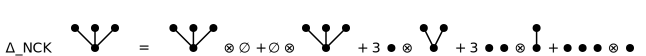

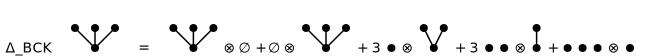

In [19]:
import kauri.bck as bck

# Corolla: same coproduct structure (up to type) in BCK and NCK
corolla_planar = PT([[], [], []])    # B+(bullet^3) as planar tree
corolla_nonplanar = kr.Tree([[], [], []])  # same as non-planar tree

kr.display("Δ_NCK", corolla_planar, "=", nck.coproduct(corolla_planar))
kr.display("Δ_BCK", corolla_nonplanar, "=", bck.coproduct(corolla_nonplanar))

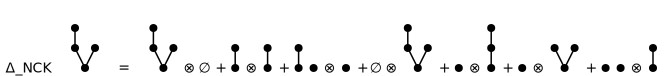

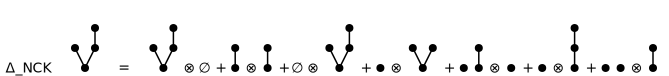

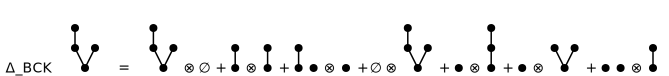

In [20]:
# Asymmetric tree: NCK distinguishes planar orderings
# These two are equal as non-planar trees but distinct as planar trees
t1_p = PT([[[]], []])   # B+(chain2, bullet)
t2_p = PT([[], [[]]])   # B+(bullet, chain2)
t_np = kr.Tree([[[]], []])   # non-planar version (unique)

kr.display("Δ_NCK", t1_p, "=", nck.coproduct(t1_p))
kr.display("Δ_NCK", t2_p, "=", nck.coproduct(t2_p))
kr.display("Δ_BCK", t_np, "=", bck.coproduct(t_np))

## 6. Convolution product

The convolution product of two scalar-valued maps $f, g$ in the NCK
Hopf algebra is

$$(f \cdot g)(t) = \mu \circ (f \otimes g) \circ \Delta_{\mathrm{NCK}}(t)$$

where $\mu$ is the (scalar) multiplication. The functions
`nck.map_product` and `nck.map_power` implement this convolution
product and its iterated powers.

**Note:** because the forest algebra is noncommutative, the convolution
product of *tree-valued* maps is not guaranteed to be associative.
The `nck.map_product` and `nck.map_power` functions are designed for
**scalar-valued maps only**.

In [21]:
# Define a scalar-valued map: f(t) = 1/nodes(t)
f = kr.Map(lambda t: 1 if t.list_repr is None else 1 / t.nodes())

# Convolution square
f_sq = nck.map_product(f, f)
# Equivalently: nck.map_power(f, 2)
f_sq_alt = nck.map_power(f, 2)

print("f^2(bullet) via map_product:", f_sq(bullet))
print("f^2(bullet) via map_power: ", f_sq_alt(bullet))
print("f^2(chain2) via map_product:", f_sq(chain2))
print("f^2(chain2) via map_power: ", f_sq_alt(chain2))

f^2(bullet) via map_product: 2.0
f^2(bullet) via map_power:  2.0
f^2(chain2) via map_product: 2.0
f^2(chain2) via map_power:  2.0


### Convolution inverse

The convolution inverse $f^{-1}$ satisfies
$f \cdot f^{-1} = \varepsilon$ (the counit). It is computed using the
NCK antipode. We verify this:

In [22]:
f_inv = nck.map_power(f, -1)                # convolution inverse
f_check = nck.map_product(f, f_inv)          # should equal counit

result = True
for t in kr.planar_trees_up_to_order(4):
    expected = 1 if t.list_repr is None else 0
    if abs(f_check(t) - expected) > 1e-12:
        result = False
        break

print("f * f^(-1) = counit:", result)

f * f^(-1) = counit: True


### Associativity of convolution

For scalar-valued maps, the convolution product is associative:
$(f \cdot g) \cdot h = f \cdot (g \cdot h)$.

In [23]:
g = kr.Map(lambda t: 1 if t.list_repr is None else t.nodes())
h = kr.Map(lambda t: 1 if t.list_repr is None else (-1) ** t.nodes())

fg_h = nck.map_product(nck.map_product(f, g), h)   # (f*g)*h
f_gh = nck.map_product(f, nck.map_product(g, h))   # f*(g*h)

result = True
for t in kr.planar_trees_up_to_order(4):
    if abs(fg_h(t) - f_gh(t)) > 1e-12:
        result = False
        break

print("Associativity of scalar convolution product:", result)

Associativity of scalar convolution product: True


### Convolution powers

We verify that `map_power(f, n)` is consistent with iterated
`map_product`:

In [24]:
f_cubed_power = nck.map_power(f, 3)
f_cubed_product = nck.map_product(nck.map_product(f, f), f)

result = True
for t in kr.planar_trees_up_to_order(4):
    if abs(f_cubed_power(t) - f_cubed_product(t)) > 1e-12:
        result = False
        break

print("map_power(f, 3) == map_product(map_product(f, f), f):", result)

map_power(f, 3) == map_product(map_product(f, f), f): True
